In [1]:
%matplotlib widget
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import scipy
import h5py

import os
import sys
sys.path.append(os.path.abspath("./"))

print(os.getpid())
%cd ../../

import pylib.mix as mix
import carleman as ca
from matplotlib import colors
plt.rcParams.update({
    "text.usetex": True,
    'text.latex.preamble': r"\usepackage{amsmath} \boldmath"
})

12180
c:\Users\ivan9\Documents\work\codes\QuCF\scripts-py


In [2]:
path_save_ = "./jupyter-notebooks/Carleman/results/"
for i in range(100):
    plt.close()

colors_     = ["blue", "red", "green", "gray", "black"]
linestyles_ = ["-", "--", "--", ":"]


System coefficients:
aa = 1.000
bb = 1.000
eps = 1.000
eta = 0.200
xi_x = 0.000
xi_y = 0.000
xi_z = 0.000

Nt: 1024
init. cond.:   0.50   0.50   0.00 




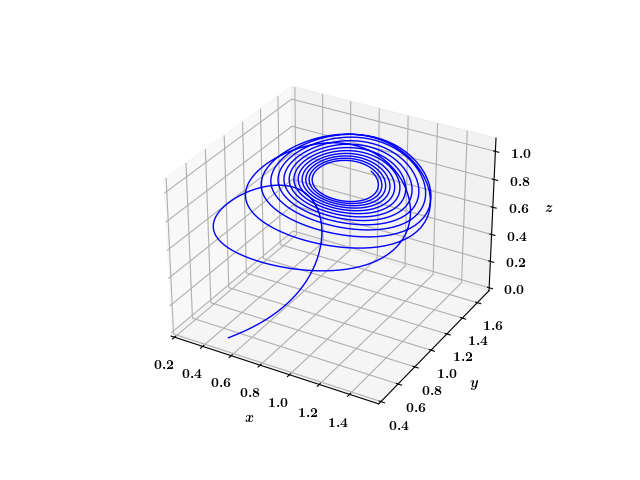

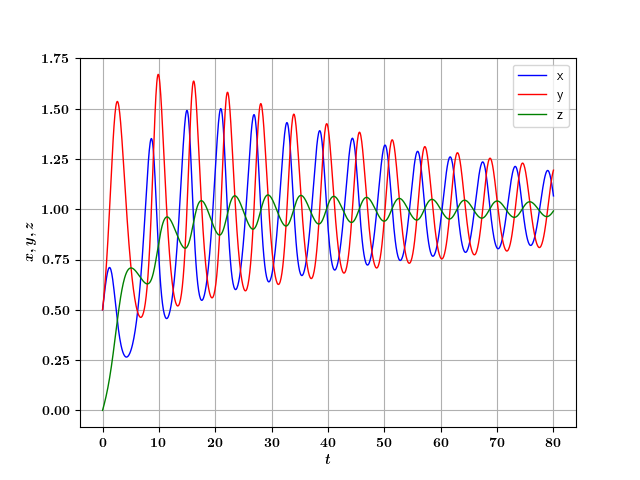

1025


In [24]:
# ---------------------------------------------------------------
# --- Prepare the system: Lotka - Volterra 3D ---
# ---------------------------------------------------------------
mix.reload_module(ca)
mix.reload_module(mix)
def choose_case(N_nl, sel_case):
    Nx = 3  # the number of degrees of freedom
    F_terms, sys_coefs, return_sys, shift_coefs = None, None, None, None
    if sel_case == 0:
        x_init = np.array([0.5, 0.5, 0.0])
        
        tmax, nt = 80, 10
        # tmax, nt = 2.4, 6  # for standard embedding

        aa, bb, eps, eta = 1.0, 1.0, 1., 0.2
        xi_x, xi_y, xi_z = 0., 0., 0.

        sys_coefs = {}
        sys_coefs["aa"]    = aa
        sys_coefs["bb"]    = bb
        sys_coefs["eps"]   = eps
        sys_coefs["eta"]   = eta
        sys_coefs["xi_x"]  = xi_x
        sys_coefs["xi_y"]  = xi_y
        sys_coefs["xi_z"]  = xi_z

        def return_sys(ss):
            aa  = ss["aa"]    
            bb  = ss["bb"]    
            eps = ss["eps"]   
            eta = ss["eta"]   
            xi_x = ss["xi_x"]  
            xi_y = ss["xi_y"]  
            xi_z = ss["xi_z"]  

            F_terms = [None] * (N_nl + 1)
            for ii_nl in range(N_nl + 1):
                F_terms[ii_nl] = np.zeros((Nx,int(Nx**ii_nl)))

            F_terms[0][0, 0] = aa * xi_x - bb * xi_x * xi_y
            F_terms[1][0, 0] = aa - bb * xi_y
            F_terms[1][0, 1] = - bb * xi_x
            F_terms[2][0, 1] = - bb

            F_terms[0][1, 0] = eps * xi_x * xi_y - eps * xi_y * xi_z
            F_terms[1][1, 0] = eps * xi_y
            F_terms[1][1, 1] = eps * xi_x - eps * xi_z
            F_terms[1][1, 2] = - eps * xi_y
            F_terms[2][1, 1] = eps
            F_terms[2][1, 5] = - eps

            F_terms[0][2, 0] = - eta * xi_z + eta * xi_y
            F_terms[1][2, 1] = eta 
            F_terms[1][2, 2] = - eta 

            return F_terms
        
        def shift_coefs(ss, zeta):
            ss_new = dict(ss)
            ss_new["xi_x"] = ss_new["xi_x"] + zeta[0]
            ss_new["xi_y"] = ss_new["xi_y"] + zeta[1]
            if "xi_z" in ss_new:
                ss_new["xi_z"] = ss_new["xi_z"] + zeta[2]
            return ss_new
        
        print("\nSystem coefficients:")
        for key, value in sys_coefs.items():
            print("{:s} = {:0.3f}".format(key, value))
        print()

        F_terms = return_sys(sys_coefs)
        F = [
            lambda x: F_terms[0][0, 0] + F_terms[1][0, 0] * x[0] + F_terms[1][0, 1] * x[1] 
                + F_terms[2][0, 1] * x[0] * x[1],
            lambda x: F_terms[0][1, 0] + F_terms[1][1, 0] * x[0] + F_terms[1][1, 1] * x[1] + F_terms[1][1, 2] * x[2] 
                + F_terms[2][1, 1] * x[0] * x[1] + F_terms[2][1, 5] * x[1] * x[2],
            lambda x: F_terms[0][2, 0] + F_terms[1][2, 1] * x[1] + F_terms[1][2, 2] * x[2],
        ]
    # ----------------------------------------------------
    return F, tmax, nt, Nx, x_init, sys_coefs, return_sys, shift_coefs
# ------------------------------------------------------------------------------
sel_case_ = 0

N_nl_orig_ = 2 
F_, tmax_, nt_, Nx_, x_init_ref_, sys_coefs_, return_sys_, shift_coefs_ = choose_case(N_nl_orig_, sel_case = sel_case_)
Nt_ = 1 << nt_
t_ = np.linspace(0, tmax_, Nt_)
dt_ = np.diff(t_)[0]

print("Nt: {:d}".format(Nt_))
print("init. cond.: ", end = "")
mix.print_array(x_init_ref_, ff = [6, 2, "f"])

# --- Standard method (for reference) ---
sol_ref_, t_ref_ = ca.analyse_classical(x_init_ref_, t_, F_)

print(len(t_ref_))

In [66]:
# --------------------------------------------------------------------
# --- Carleman linearization ---
# --------------------------------------------------------------------
mix.reload_module(ca)
N_nl = 6   # should be >= N_nl_orig_
flag_max_error_ = True
case_sim_, step_t_ = "LV3D", 1
radii_emb_ = None

# # --- Standard embedding ---
# sol_emb_, t_emb_, case_emb_ = ca.solve_carleman_orig(x_init_ref_, N_nl, N_nl_orig_, t_, return_sys_(sys_coefs_))

# # --- Piecewise embedding ---
# zeta_th = 0.1
# sol_emb_, t_emb_, case_emb_ = ca.solve_carleman_global(
#     x_init_ref_, N_nl, N_nl_orig_, t_, 
#     sys_coefs_, return_sys_, shift_coefs_,
#     zeta_th = zeta_th
# )
# step_t_ = 6
# del zeta_th


# --- Piecewise adaptive embedding ---
# err_tol, zeta_max, zeta_step = 1.e-7, 1.0, 0.02
# err_tol, zeta_max, zeta_step = 1.e-7, 0.8, 0.02
# err_tol, zeta_max, zeta_step = 1.e-9, 0.8, 0.02
# err_tol, zeta_max, zeta_step = 1.e-9, 0.6, 0.02

err_tol, zeta_max, zeta_step = 1.e-7, 1.0, 0.20

sol_emb_, t_emb_, case_emb_, radii_emb_ = ca.solve_carleman_global_adaptive(
    x_init_ref_, N_nl, N_nl_orig_, t_, 
    sys_coefs_, return_sys_, shift_coefs_,
    zeta_init_ = zeta_max, 
    err_tolerance_ = err_tol,
    zeta_min_    = 1e-3,
    zeta_step_   = zeta_step,
    zeta_thresh_ = 0.22,
    zeta_max_ = zeta_max
)
case_sim_ = "LV3D_max{:0.2f}_tol{:0.3e}_dx{:0.2f}".format(zeta_max, err_tol, zeta_step)
step_t_ = 1
del err_tol, zeta_max, zeta_step


--- t, zeta: 2.044e+00, 1.000e+00 ---

--- t, zeta: 6.122e+00, 1.000e+00 ---

--- t, zeta: 8.557e+00, 1.000e+00 ---
Take a smaller chart: new zeta = 8.000e-01

--- t, zeta: 9.585e+00, 8.000e-01 ---

--- t, zeta: 1.124e+01, 8.000e-01 ---

--- t, zeta: 1.367e+01, 8.000e-01 ---

--- t, zeta: 1.525e+01, 8.000e-01 ---

--- t, zeta: 1.643e+01, 8.000e-01 ---

--- t, zeta: 1.793e+01, 8.000e-01 ---

--- t, zeta: 2.029e+01, 8.000e-01 ---

--- t, zeta: 2.171e+01, 8.000e-01 ---

--- t, zeta: 2.352e+01, 8.000e-01 ---

--- t, zeta: 2.611e+01, 8.000e-01 ---

--- t, zeta: 2.768e+01, 8.000e-01 ---

--- t, zeta: 2.973e+01, 8.000e-01 ---

--- t, zeta: 3.263e+01, 8.000e-01 ---
Take a smaller chart: new zeta = 6.000e-01

--- t, zeta: 3.366e+01, 6.000e-01 ---
Take a larger chart: new zeta = 8.000e-01

--- t, zeta: 3.617e+01, 8.000e-01 ---
Take a smaller chart: new zeta = 6.000e-01

--- t, zeta: 3.806e+01, 6.000e-01 ---

--- t, zeta: 4.988e+01, 6.000e-01 ---

--- t, zeta: 8.000e+01, 6.000e-01 ---
Done


In [55]:
step_t_ = 1
len(t_emb_)

1194

write data to a file: ./jupyter-notebooks/Carleman/results//REF_LV3D_max1.00_tol1.000e-07_dx0.20_xyz.dat
write data to a file: ./jupyter-notebooks/Carleman/results//EMB_LV3D_max1.00_tol1.000e-07_dx0.20_PAE_xyz.dat
write data to a file: ./jupyter-notebooks/Carleman/results//REF_LV3D_max1.00_tol1.000e-07_dx0.20_x.dat
write data to a file: ./jupyter-notebooks/Carleman/results//EMB_LV3D_max1.00_tol1.000e-07_dx0.20_PAE_x.dat
write data to a file: ./jupyter-notebooks/Carleman/results//REF_LV3D_max1.00_tol1.000e-07_dx0.20_y.dat
write data to a file: ./jupyter-notebooks/Carleman/results//EMB_LV3D_max1.00_tol1.000e-07_dx0.20_PAE_y.dat
write data to a file: ./jupyter-notebooks/Carleman/results//REF_LV3D_max1.00_tol1.000e-07_dx0.20_z.dat
write data to a file: ./jupyter-notebooks/Carleman/results//EMB_LV3D_max1.00_tol1.000e-07_dx0.20_PAE_z.dat
write data to a file: ./jupyter-notebooks/Carleman/results//EMB_LV3D_max1.00_tol1.000e-07_dx0.20_PAE_max_err.dat
write data to a file: ./jupyter-notebooks/C

c:\Users\ivan9\Documents\work\codes\QuCF\scripts-py\jupyter-notebooks\Carleman\carleman.py:1090: RuntimeWarning: invalid value encountered in divide
  errs[ivar] = abs(s_ref[ivar] - s_emb_int[ivar]) / abs(s_ref[ivar])
c:\Users\ivan9\Documents\work\codes\QuCF\scripts-py\jupyter-notebooks\Carleman\carleman.py:1121: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


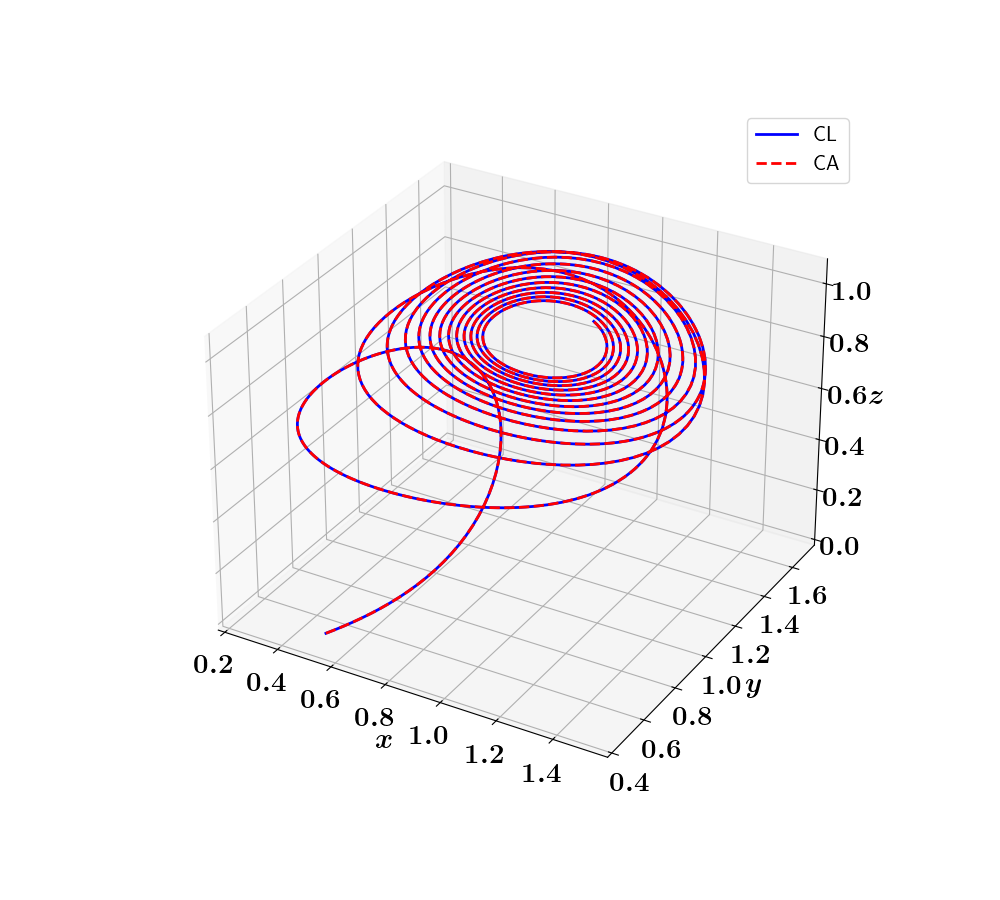

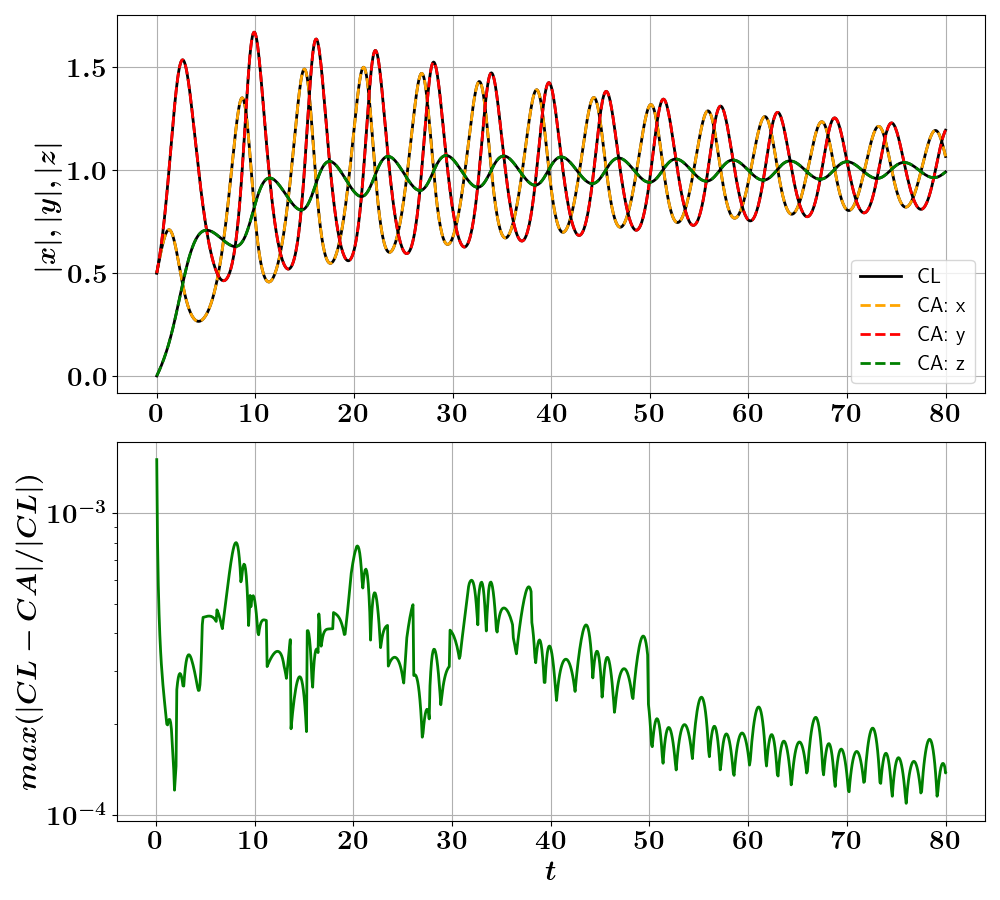

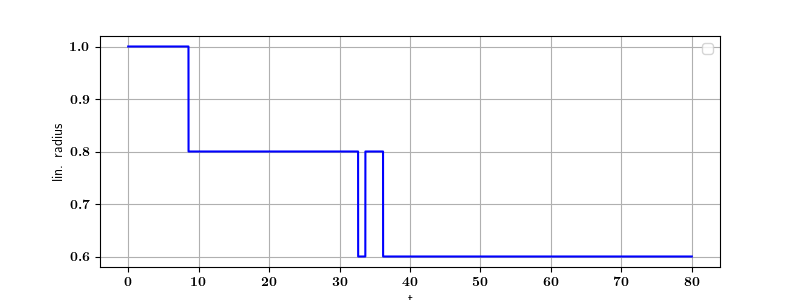

In [67]:
# --------------------------------------------------------------------
# --- Compare trajectories ---
# --------------------------------------------------------------------
mix.reload_module(ca)
ca.compare_trajectory_cl_and_carleman(
    t_ref_, sol_ref_, t_emb_, sol_emb_,
    flag_save=True, path_save=path_save_, 
    case_title = case_sim_, case_emb = case_emb_,
    fontsize = 20, fig_size = (10,9),
    radii_emb = radii_emb_,
    flag_var_semilogy = False,
    step_t = step_t_,
    flag_max_error = flag_max_error_
)